# 03 - Análise Exploratória

- Objetivo: Analisar evolução da taxa SELIC, do IPCA e do câmbio USD/BRL no Brasil nos últimos 5 anos, buscando identificar padrões, momentos de inflexão e possíveis relações entre os indicadores.

### Perguntas de análise

- As análises deste notebook buscam responder às seguintes perguntas:

1. Como a SELIC evoluiu nos últimos 5 anos e quais foram os momentos de inflexão?
2. Existe correlação entre a taxa SELIC e o IPCA (inflação)?
3. Como o câmbio USD/BRL reagiu às mudanças na taxa de juros?
4. Qual período foi o mais crítico para a economia brasileira no intervalo analisado?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/processed/macro_mensal.csv')

In [4]:
df.head(5)

,data,selic,ipca,cambio
0,2020-01-31,4.50,0.21,4.149464
1,2020-02-29,4.25,0.25,4.341011
2,2020-03-31,3.75,0.07,4.883855
3,2020-04-30,3.75,-0.31,5.325580
4,2020-05-31,3.00,-0.38,5.643445


In [5]:
df.dtypes

data       object
selic     float64
ipca      float64
cambio    float64
dtype: object

In [6]:
df['data'] = pd.to_datetime(df['data'])

In [7]:
print(df.dtypes)

data      datetime64[ns]
selic            float64
ipca             float64
cambio           float64
dtype: object


In [8]:
df['data'].max()

Timestamp('2026-06-30 00:00:00')

In [9]:
df = df.set_index('data')
df.index = pd.to_datetime(df.index)

In [10]:
data_maxima = df.index.max()
data_de_corte = data_maxima - pd.DateOffset(years=5)

In [11]:
# SELIC últimos 5 anos
evolucao_selic = df[(df.index <= data_maxima) & (df.index >= data_de_corte)]

In [12]:
evolucao_selic = evolucao_selic.sort_values('data')

In [13]:
evolucao_selic.head(5)

,selic,ipca,cambio
data,,,
2021-06-30,4.25,0.53,5.031905
2021-07-31,4.25,0.96,5.156705
2021-08-31,5.25,0.87,5.251718
2021-09-30,6.25,1.16,5.279690
2021-10-31,7.75,1.25,5.539980


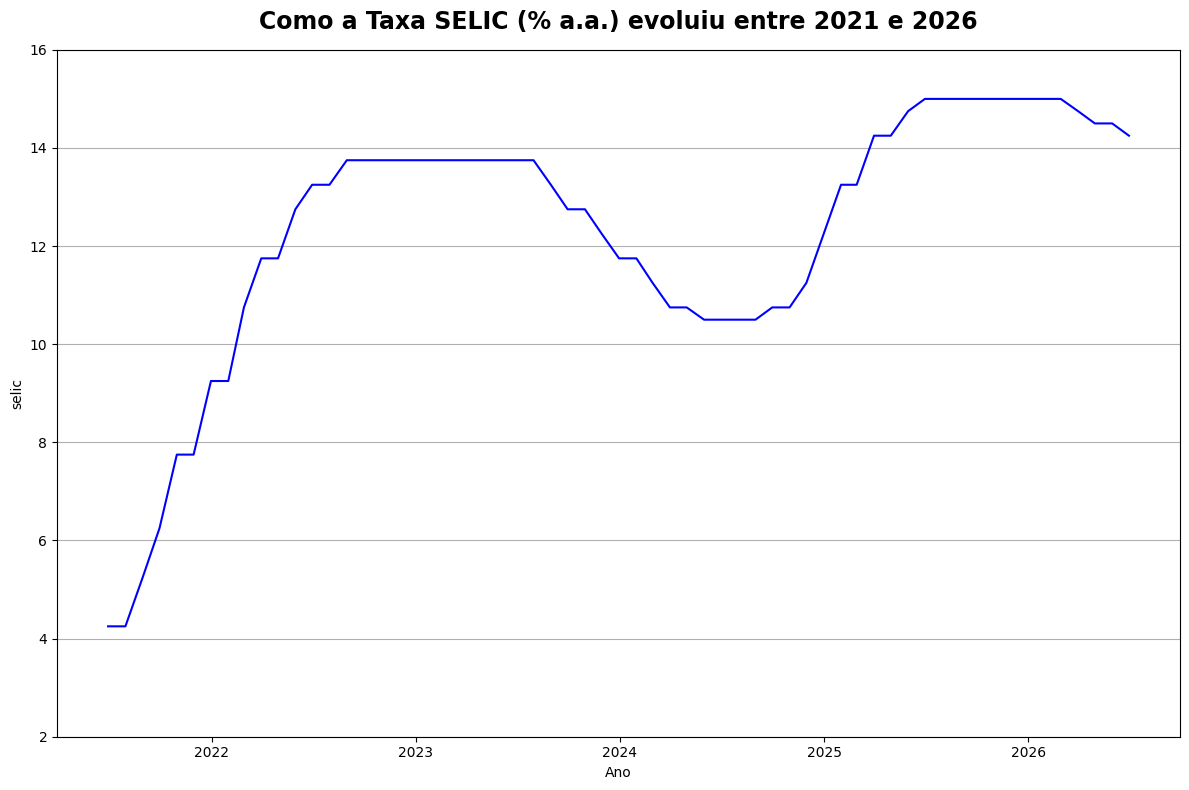

In [14]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=evolucao_selic, x='data', y='selic', color='blue')
plt.title(f'Como a Taxa SELIC (% a.a.) evoluiu entre {data_de_corte.year} e {data_maxima.year}', fontsize=17, pad=15, fontweight="bold")
plt.xlabel('Ano')
plt.yticks([2, 4, 6, 8, 10, 12, 14, 16])
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('../figures/evolucao_selic', dpi=150, bbox_inches='tight')
plt.show()

- Entre 2021 e 2023, a SELIC saiu de 4,25% e atingiu 13,75%, reflexo da política do Banco Central para conter a inflação que disparou no pós-pandemia. A partir de 2024 houve um ciclo de queda, mas em 2025 o Copom retomou as altas, levando a taxa ao pico de 15%. Em junho de 2026, a taxa recuou para 14,25%, sinalizando um possível novo ciclo de afrouxamento monetário

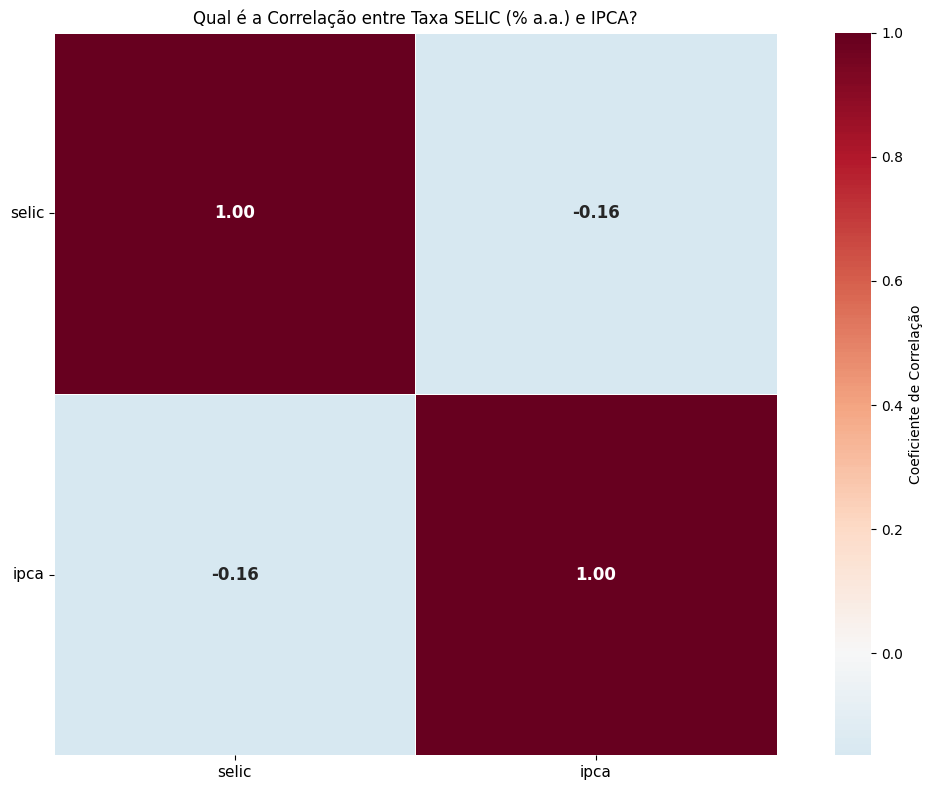

In [15]:
corr = df[['selic', 'ipca']].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr, 
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Coeficiente de Correlação'},
    annot_kws={
        'fontsize': 12,
        'fontweight': 'bold'
    }
)

plt.title('Qual é a Correlação entre Taxa SELIC (% a.a.) e IPCA?')
plt.xticks(fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('../figures/correlacao_ipca_selic', dpi=150, bbox_inches='tight')
plt.show()

- A correlação de -0.16 indica uma relação negativa fraca entre SELIC e IPCA no período. Quando a SELIC sobe, o IPCA tende a cair, mas o efeito é pequeno nos dados mensais porque a política monetária leva de 6 a 12 meses para impactar a inflação de fato.

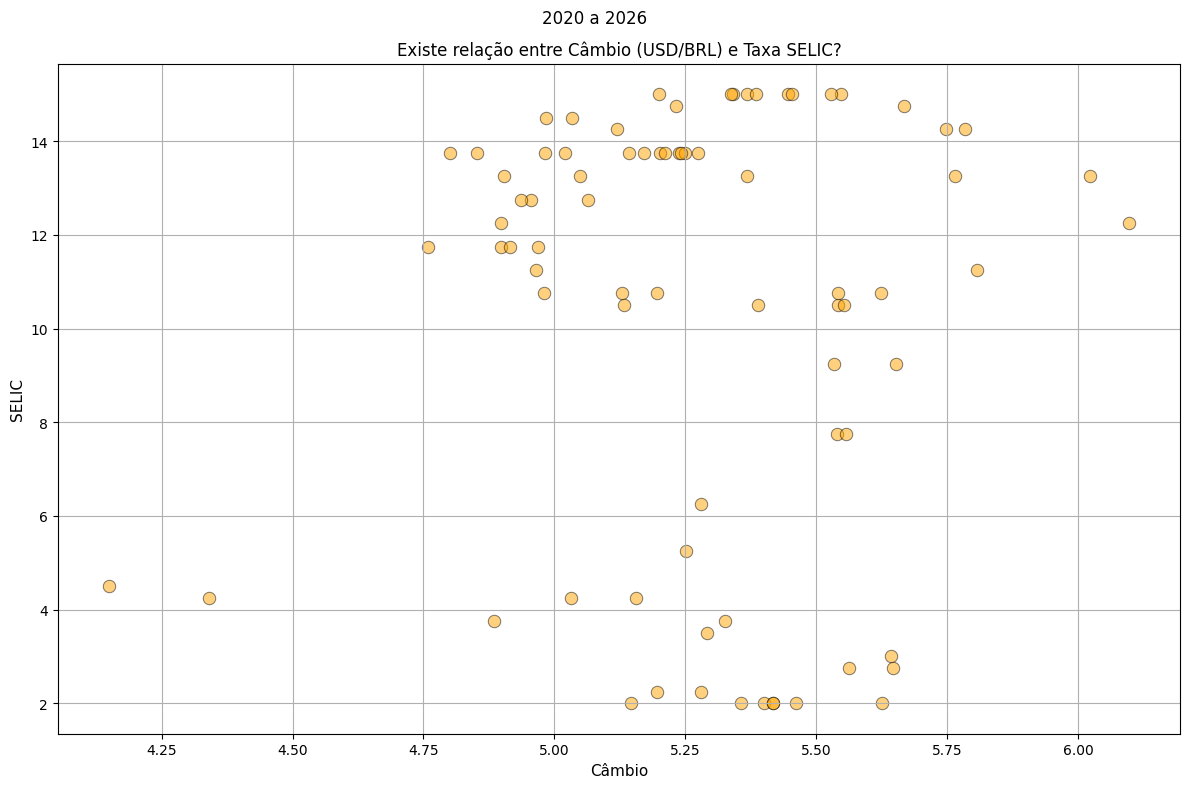

In [37]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='cambio',
    y='selic',
    s=80,
    alpha=0.5,
    color='orange',
    edgecolor='black'
    )
plt.title('Existe relação entre Câmbio (USD/BRL) e Taxa SELIC?')
plt.suptitle('2020 a 2026')
plt.xlabel('Câmbio', fontsize=11)
plt.ylabel('SELIC', fontsize=11)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../figures/cambio_vs_selic.png', dpi=150, bbox_inches='tight')
plt.show()

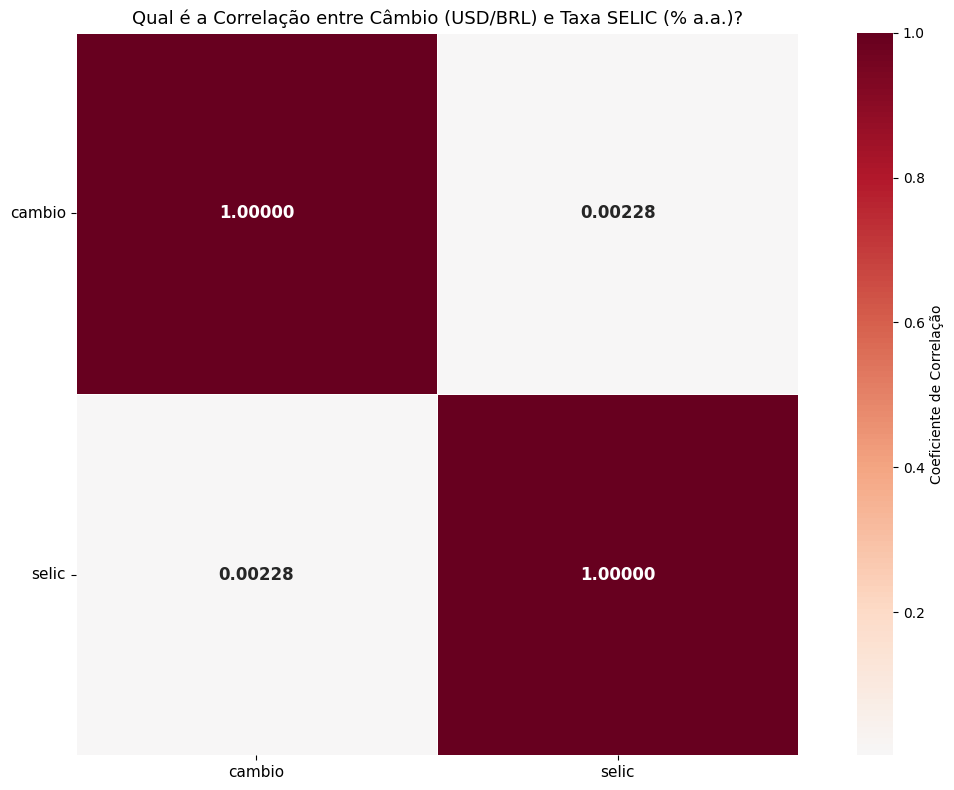

In [60]:
corr_cambio_vs_selic = df[['cambio', 'selic']].corr()
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_cambio_vs_selic,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.5f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Coeficiente de Correlação'},
    annot_kws={
        'fontsize': 12,
        'fontweight': 'bold'
    }
)   
plt.title('Qual é a Correlação entre Câmbio (USD/BRL) e Taxa SELIC (% a.a.)?', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('../figures/correlacao_cambio_vs_selic.png', dpi=150, bbox_inches='tight')
plt.show()


- A correlação de 0,002 entre o câmbio (USD/BRL) e a taxa SELIC mostra que, no período analisado (2020–2026), praticamente não houve relação linear entre essas duas variáveis. Embora a teoria econômica indique que juros mais altos tendem a atrair investimentos estrangeiros e fortalecer o real, outros fatores tiveram maior influência sobre a cotação do dólar nesse período. Eventos como a pandemia, as incertezas fiscais e o cenário econômico internacional acabaram reduzindo o impacto esperado da política monetária sobre o câmbio.

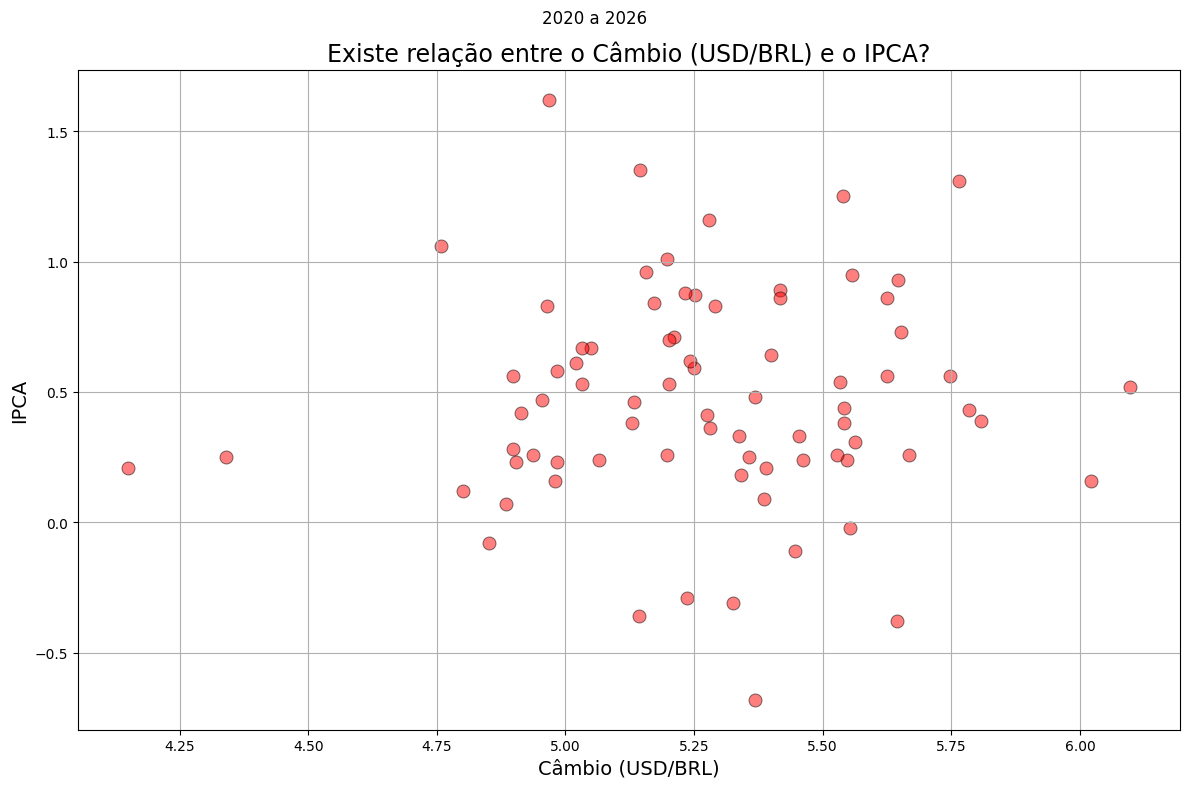

In [61]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    df,
    x='cambio',
    y='ipca',
    color='#FF0000',
    s=87,
    edgecolor='black',
    alpha=0.5
)
plt.suptitle('2020 a 2026')
plt.title('Existe relação entre o Câmbio (USD/BRL) e o IPCA?', fontsize=17)
plt.xlabel('Câmbio (USD/BRL)', fontsize=14)
plt.ylabel('IPCA', fontsize=14)
plt.grid(axis='both')
plt.tight_layout()
plt.savefig('../figures/cambio_vs_ipca.png', dpi=150, bbox_inches='tight')
plt.show()

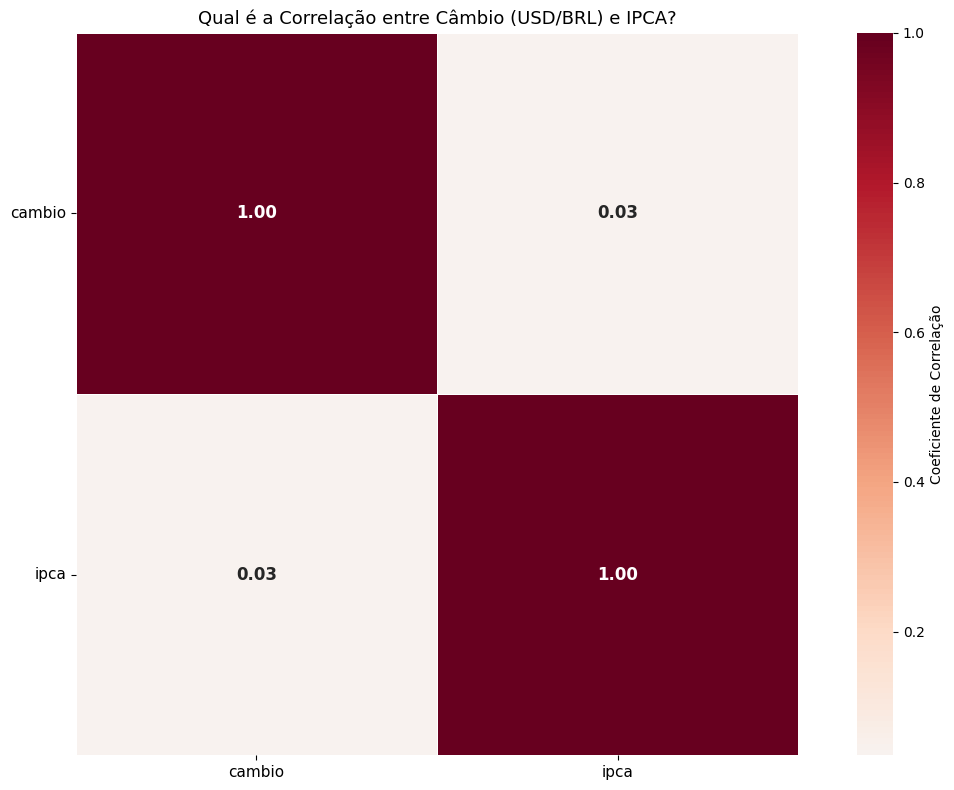

In [70]:
corr_cambio_vs_ipca = df[['cambio', 'ipca']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_cambio_vs_ipca,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Coeficiente de Correlação'},
    annot_kws={
        'fontsize': 12,
        'fontweight': 'bold'
    }
)
plt.title('Qual é a Correlação entre Câmbio (USD/BRL) e IPCA?', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('../figures/correlacao_cambio_vs_ipca.png', dpi=150, bbox_inches='tight')
plt.show()

- A correlação de 0,03 entre o câmbio (USD/BRL) e o IPCA indica que, no período analisado (2020–2026), praticamente não houve uma relação linear entre essas variáveis. Embora seja esperado que a alta do dólar contribua para o aumento da inflação, principalmente pelo encarecimento de produtos importados, os dados sugerem que outros fatores tiveram maior influência sobre o IPCA. Entre eles estão os choques de oferta, as oscilações nos preços da energia e dos alimentos, que acabaram reduzindo o impacto direto da variação cambial sobre a inflação.